# Defining the upwelling region 

In [132]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm
import matplotlib.pyplot as plt

In [133]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [134]:
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
wmld = wmld.sel(lon=slice(-85,None),lat=slice(-17,-4))
wmld

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    WMLD     (time, lat, lon) float64 107MB 1.035e-06 -1.454e-06 ... nan nan

In [143]:
mask = coastal_band_mask(wmld, var='WMLD', target_width_km=500) # ~111 km cross-shore
WMLD = wmld.where(mask).sel(lon=slice(-85, None), lat=slice(-17,-4))

In [144]:
# ============================================================
# 3. Find coastal and offshore boundary longitudes per latitude
# ============================================================
valid = np.isfinite(WMLD.WMLD.isel(time=0))
valid_e = valid.shift(lon=-1).fillna(False).astype(bool)
valid_w = valid.shift(lon=+1).fillna(False).astype(bool)

coast_mask = valid & (~valid_e)      # easternmost valid cell (coast)
offshore_mask = valid & (~valid_w)   # westernmost valid cell (offshore edge)

lat_all = wmld.lat.values
lon_all = wmld.lon.values

coast_lons = np.full(len(lat_all), np.nan)
offshore_lons = np.full(len(lat_all), np.nan)

for j in range(len(lat_all)):
    cols_e = np.where(coast_mask.isel(lat=j).values)[0]
    if len(cols_e) > 0:
        coast_lons[j] = lon_all[cols_e[0]]
    cols_w = np.where(offshore_mask.isel(lat=j).values)[0]
    if len(cols_w) > 0:
        offshore_lons[j] = lon_all[cols_w[0]]

Text(0.5, 1.0, 'coast / offshore boundary detection')

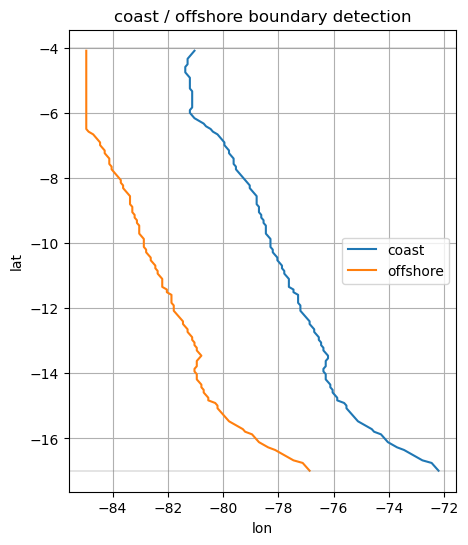

In [145]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(coast_lons, lat_all, label='coast')
ax.plot(offshore_lons, lat_all, label='offshore')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
ax.axhline(-4,  color='grey', lw=0.3)
ax.axhline(-17, color='grey', lw=0.3)
ax.legend(); ax.grid(True)
ax.set_title('coast / offshore boundary detection')

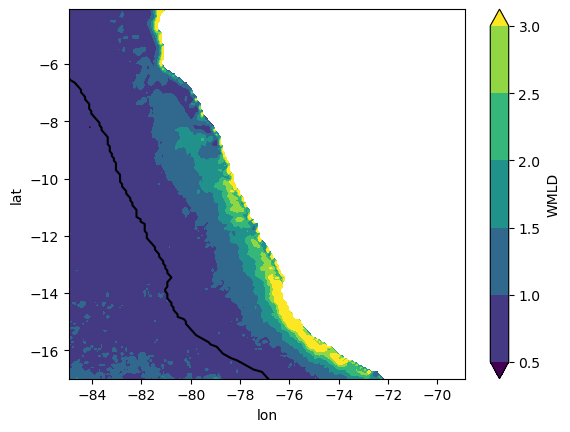

In [137]:
(wmld*60*60*24).std('time').WMLD.plot.contourf(robust=True)
plt.plot(offshore_lons, lat_all, label='offshore',color='black')

In [41]:
## time
lonis = []
thris = []
wis = []

W = (wmld*60*60*24)

for i in tqdm(range(0,len(wmld.time))):

    w = W.sel(lat=slice(-15.5,-15)).isel(time=i).mean(dim=('lat')).WMLD
    thr = W.sel(lat=slice(-15.5,-15)).isel(time=i).mean(dim=('lat')).WMLD.quantile(0.95)
    # print(thr)
    # print(wmld.time[i].data)
    
    # w.plot()
    # plt.hlines(thr,-84,-70,color='black')
    
    loni = w.where(w>=thr).dropna(dim='lon').lon.max()
    
    lonis.append(loni.data)
    thris.append(thr.data)
    wis.append(w.data)


100%|█████████████████████████████████████████████████████████████████████████████████| 432/432 [00:00<00:00, 493.50it/s]


In [88]:
#latitude
lonis = []
thris = []
wis = []
i=0
W = (wmld*60*60*24).WMLD

for j in tqdm(range(len(wmld.lat.data)-1)):
    w = W.isel(time=i,lat=slice(j,j+1))
    thr = W.isel(time=i,lat=slice(j,j+1)).quantile(0.95)
    
    loni = w.where(w>=thr).dropna(dim='lon').lon.max()

    lonis.append(loni.data)
    thris.append(thr.data)
    wis.append(w.data)
    

# w.plot()
# plt.hlines(thr,-84,-70,color='black')

100%|█████████████████████████████████████████████████████████████████████████████████| 158/158 [00:00<00:00, 620.22it/s]


<xarray.DataArray 'lon' ()> Size: 8B
array(-81.2)
Coordinates:
    time      datetime64[ns] 8B 1980-01-31
    quantile  float64 8B 0.95


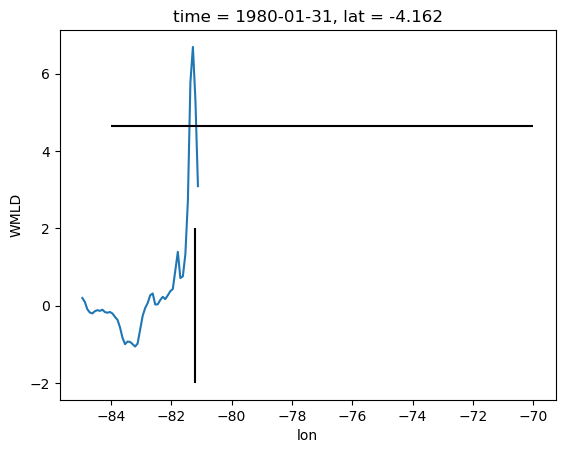

In [89]:
# j=1
# i=1
W = (wmld*60*60*24).WMLD

w = W.isel(time=i,lat=slice(j,j+1))
thr = W.isel(time=i,lat=slice(j,j+1)).quantile(0.95)

w.plot()
plt.hlines(thr,-84,-70,color='black')

loni = w.where(w>=thr).dropna('lon').lon.max()
plt.vlines(loni,-2,2,color='black')
print(loni)

In [90]:
# plt.plot(wmld.time,np.array(thris))
np.array(thris).mean()

1.0803581176650696

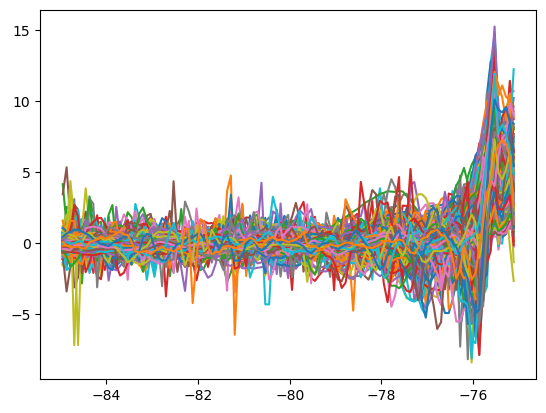

In [12]:
plt.plot(w.lon.data,np.array(wis).T)

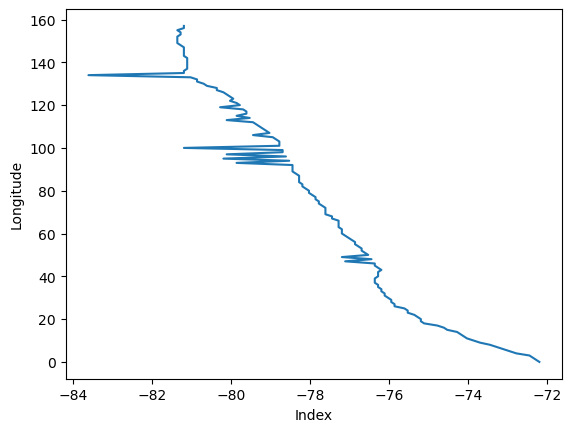

-77.93734177215191


In [102]:
plt.plot(lonis,range(len(lonis)))
plt.xlabel('Index')
plt.ylabel('Longitude')
plt.show()

print(np.array(lonis).mean())

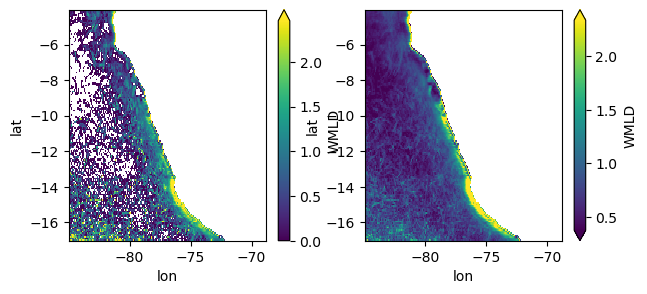

In [44]:
# (wmld*60*60*24).WMLD.where(wmld.WMLD<=1.1715837025647202,np.nan).mean('time').plot()
tt = np.array(thris).mean() 
tmin = np.array(thris).min() 

W = (wmld * 60*60*24).WMLD  # m/day

W_masked = W.where(W >= tt)
W_masked_min = W.where(W >= tmin)

fig,ax = plt.subplots(1,2,figsize=(7,3))

W_masked.std('time').plot(robust=True,ax=ax[0])
W_masked_min.std('time').plot(robust=True,ax=ax[1])

In [114]:
W = (wmld * 60 * 60 * 24).WMLD

all_lonis = []  # will become (time, lat)

for i in tqdm(range(len(wmld.time))):
    row_lonis = []
    for j in range(len(wmld.lat.data) - 1):
        w = W.isel(time=i, lat=slice(j, j+1))
        thr = w.quantile(0.90)

        filtered = w.where(w >= thr).dropna(dim='lon')

        if len(filtered.lon) > 0:
            row_lonis.append(float(filtered.lon.max()))
        else:
            row_lonis.append(np.nan)

    all_lonis.append(row_lonis)

# Wrap into xarray
loni_da = xr.DataArray(
    np.array(all_lonis),
    dims=('time', 'lat'),
    coords={
        'time': wmld.time.values,
        'lat':  wmld.lat.values[:-1],
    },
    name='lon_upwelling_edge',
)

100%|██████████████████████████████████████████████████████████████████████████████████| 432/432 [01:56<00:00,  3.71it/s]


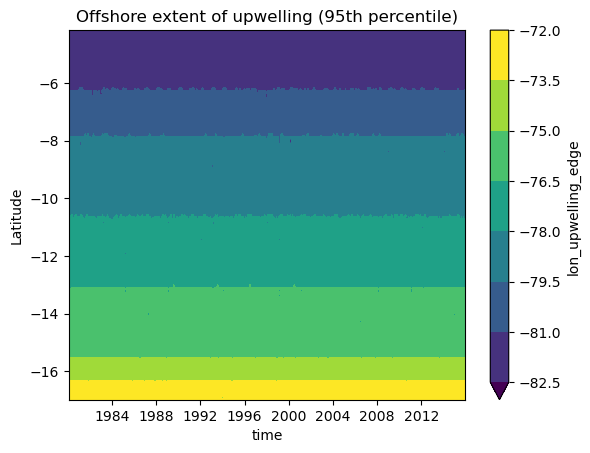

In [115]:
loni_da.plot.contourf(x='time', y='lat', cmap='viridis',robust=True)
plt.title('Offshore extent of upwelling (95th percentile)')
plt.ylabel('Latitude')
plt.show()

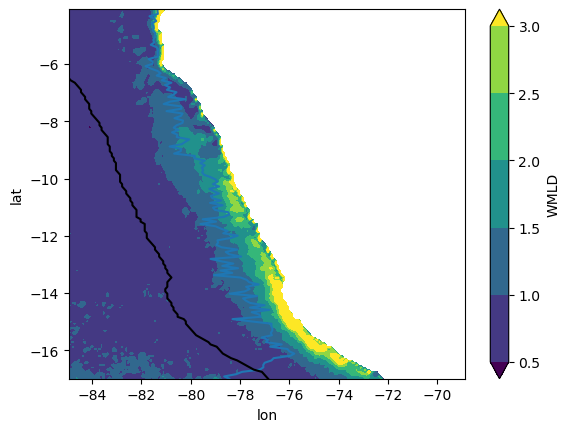

In [138]:
loni_da.mean('time').plot(y='lat')
(wmld*60*60*24).std('time').WMLD.plot.contourf(robust=True)
plt.plot(offshore_lons, lat_all, label='offshore',color='black')

In [141]:
# 1. Ensure your data is 'chunked' to allow Dask to work
# Adjust chunks based on your HPC memory (e.g., {'time': 10, 'lat': 100})
W = (wmld * 60 * 60 * 24).WMLD.chunk({'time': 20, 'lat': 200})

# 2. Vectorized Quantile Calculation
# This calculates the 90th percentile across the 'lon' dimension for ALL time and lat at once
thresholds = W.quantile(0.90, dim='lon')

# 3. Vectorized Masking
# Keep only values that are >= the calculated threshold
# .where sets everything else to NaN
masked_W = W.where(W >= thresholds)

# 4. Extract the max longitude
# We use the longitude coordinates, keeping only where the condition is met, 
# and taking the max along the 'lon' dimension.
loni_da = masked_W.lon.where(masked_W.notnull()).min(dim='lon')

# 5. Compute (This is where Dask triggers the parallel execution)
# If your data is very large, this may take a moment.
loni_da = loni_da.compute()

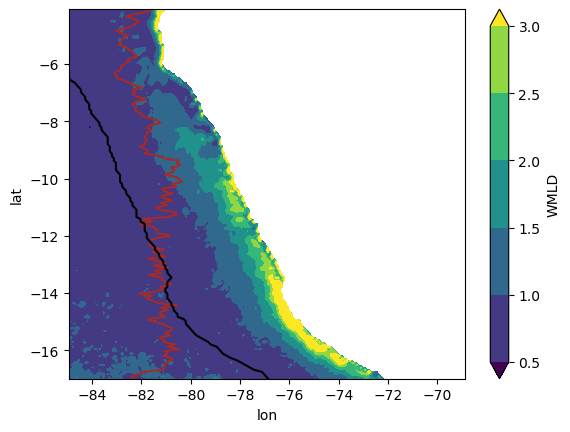

In [142]:
loni_da.mean('time').plot(y='lat',color='brown')
(wmld*60*60*24).std('time').WMLD.plot.contourf(robust=True)
plt.plot(offshore_lons, lat_all, label='offshore',color='black')